In [1]:
# Session 13

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [4]:
df = pd.read_csv('cp_data_demo.csv')
print(f"Initial row count: {len(df)}")

Initial row count: 4577


Rows dropped due to NaN: 13
Rows dropped due to unphysical values (T < 0 or Cp < 0): 0
Final cleaned dataset row count: 4564


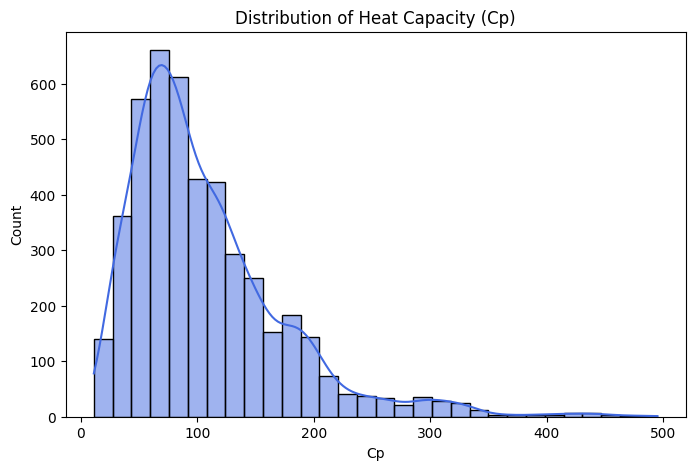

In [5]:
# Rename columns to standard schema (formula, T, Cp)[cite: 16]
df = df.rename(columns={'Formula': 'formula', 'Temperature': 'T', 'Heat_Capacity': 'Cp'})
count_before_dropna = len(df)
df = df.dropna(subset=['formula', 'T', 'Cp'])
print(f"Rows dropped due to NaN: {count_before_dropna - len(df)}")
valid_mask = (df['T'] >= 0) & (df['Cp'] >= 0)
dropped_unphysical = (~valid_mask).sum()
df_clean = df[valid_mask].copy()
print(f"Rows dropped due to unphysical values (T < 0 or Cp < 0): {dropped_unphysical}")
print(f"Final cleaned dataset row count: {len(df_clean)}")
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Cp'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Heat Capacity (Cp)')
plt.xlabel('Cp')
plt.ylabel('Count')
plt.show()

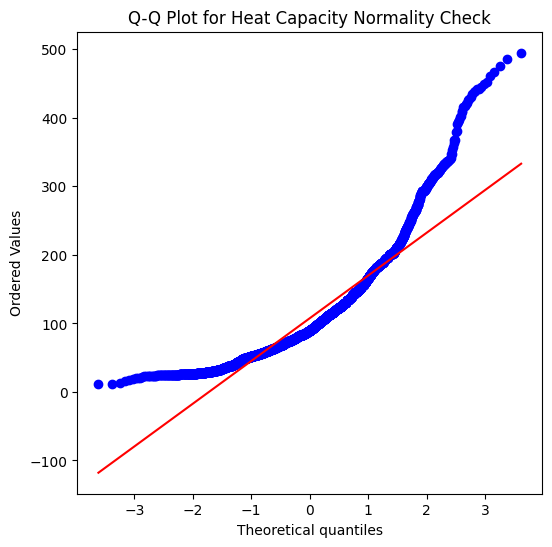

In [6]:
# 6. Perform a Q-Q normality check[cite: 16]
plt.figure(figsize=(6, 6))
stats.probplot(df_clean['Cp'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Heat Capacity Normality Check')
plt.show()

In [7]:
# Save the cleaned dataset deliverable
df_clean.to_csv('cleaned_cp_dataset.csv', index=False)
print("✅ Cleaned Cp dataset successfully saved and ready for commit.")

✅ Cleaned Cp dataset successfully saved and ready for commit.


In [8]:
df = pd.read_csv('cleaned_cp_dataset.csv')
sample_materials = df['formula'].unique()[:5]


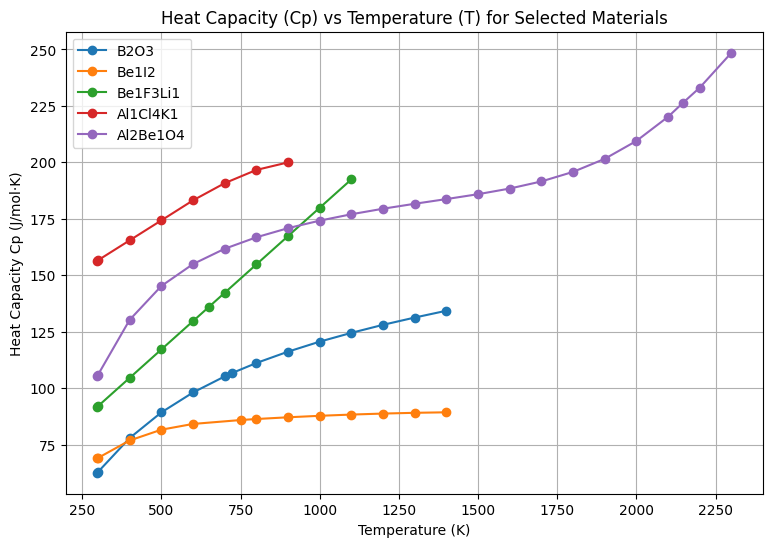

In [9]:
plt.figure(figsize=(9, 6))
for mat in sample_materials:
    subset = df[df['formula'] == mat]
    plt.plot(subset['T'], subset['Cp'], marker='o', label=mat)

plt.title('Heat Capacity (Cp) vs Temperature (T) for Selected Materials')
plt.xlabel('Temperature (K)')
plt.ylabel('Heat Capacity Cp (J/mol·K)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
def classify_family(formula):
    if 'O' in formula and 'C' not in formula and 'N' not in formula:
        return 'Oxide'
    elif 'C' in formula:
        return 'Carbide'
    elif 'N' in formula:
        return 'Nitride'
    else:
        return 'Other'

df['family'] = df['formula'].apply(classify_family)
df_grouped = df[df['family'].isin(['Oxide', 'Carbide', 'Nitride'])]
family_stats = df_grouped.groupby(['family', 'T'])['Cp'].agg(['mean', 'std']).reset_index()
print("✅ Chemical family grouping and statistical aggregation complete.")

✅ Chemical family grouping and statistical aggregation complete.
